In [3]:
import os
import gc
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K

# 1. Setup Directories
PLOTS_DIR = 'plots'
RESULTS_DIR = 'results'
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
global_metrics = {} # To store results for the final tables

print("--- DOWNLOADING AND PREPARING MNIST SUBSET ---")
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Use subset: 10,000 train, 2,000 test
X_train = X_train_full[:10000].astype('float32') / 255.
X_test = X_test_full[:2000].astype('float32') / 255.
y_train = y_train_full[:10000]
y_test = y_test_full[:2000]

# Spatial Format (for CAE and VAE): (N, 28, 28, 1)
X_train_sp = np.expand_dims(X_train, axis=-1)
X_test_sp = np.expand_dims(X_test, axis=-1)

# Flattened Format (for FC-AE): (N, 784)
X_train_flat = X_train.reshape((len(X_train), 784))
X_test_flat = X_test.reshape((len(X_test), 784))

print(f"Spatial Train Shape   : {X_train_sp.shape}")
print(f"Flattened Train Shape : {X_train_flat.shape}")
print(f"Spatial Test Shape    : {X_test_sp.shape}")

# Helper Function: Calculate MSE, MAE, SSIM
def evaluate_reconstruction(y_true, y_pred, is_flat=False):
    if is_flat:
        y_true = y_true.reshape(-1, 28, 28)
        y_pred = y_pred.reshape(-1, 28, 28)
    else:
        y_true = y_true.squeeze()
        y_pred = y_pred.squeeze()

    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))

    # Calculate SSIM per image and average
    ssim_vals = [ssim(y_true[i], y_pred[i], data_range=1.0) for i in range(len(y_true))]
    mean_ssim = np.mean(ssim_vals)
    return mse, mae, mean_ssim

print("Cell 1 Complete. Dataset and utilities are ready.")

--- DOWNLOADING AND PREPARING MNIST SUBSET ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Spatial Train Shape   : (10000, 28, 28, 1)
Flattened Train Shape : (10000, 784)
Spatial Test Shape    : (2000, 28, 28, 1)
Cell 1 Complete. Dataset and utilities are ready.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



--- 1. FULLY CONNECTED AUTOENCODER (FC-AE) ---


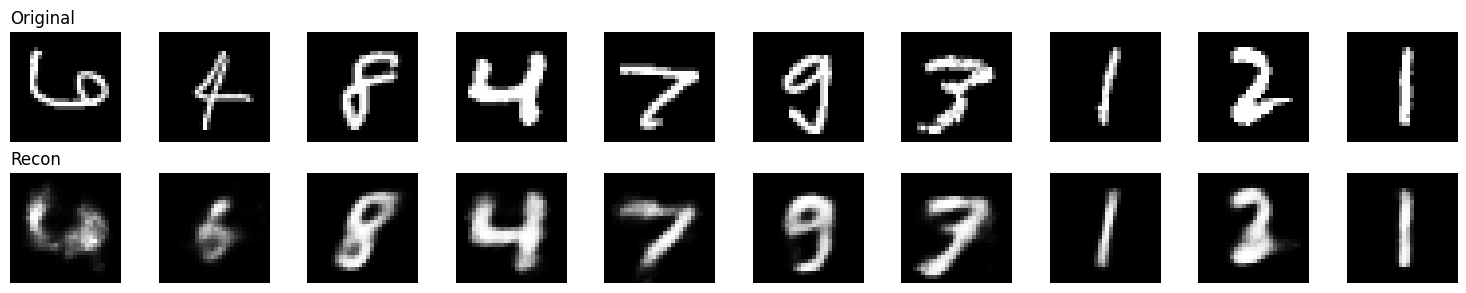

[Inference - Plot 1]: The digit shape is generally preserved, but fine details (like crisp edges) are lost. Blurred regions occur because the network acts as a lossy compressor, averaging out complex strokes into generalized blobs.


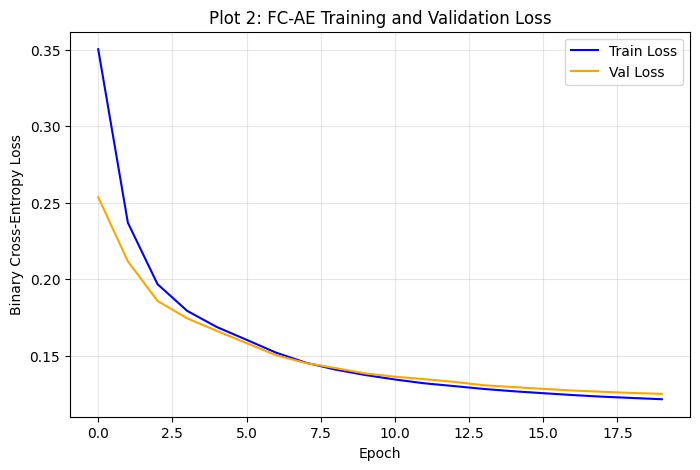

[Inference - Plot 2]: The model converges rapidly within the first 5 epochs. The validation loss tracks closely with the training loss, indicating no significant overfitting.


In [5]:
print("\n--- 1. FULLY CONNECTED AUTOENCODER (FC-AE) ---")
K.clear_session()

# Build FC-AE
fc_input = layers.Input(shape=(784,))
x = layers.Dense(128, activation='relu')(fc_input)
x = layers.Dense(32, activation='relu')(x)
latent_fc = layers.Dense(16, activation='relu')(x)
x = layers.Dense(32, activation='relu')(latent_fc)
x = layers.Dense(128, activation='relu')(x)
fc_output = layers.Dense(784, activation='sigmoid')(x)

fc_ae = models.Model(fc_input, fc_output)
fc_ae.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')

start_time = time.time()
hist_fc = fc_ae.fit(X_train_flat, X_train_flat, epochs=20, batch_size=128, validation_data=(X_test_flat, X_test_flat), verbose=0)
fc_time = time.time() - start_time

# Predict & Evaluate
X_pred_fc_flat = fc_ae.predict(X_test_flat, verbose=0)
X_pred_fc = X_pred_fc_flat.reshape(-1, 28, 28, 1) # Reshape for later plotting
mse_fc, mae_fc, ssim_fc = evaluate_reconstruction(X_test_flat, X_pred_fc_flat, is_flat=True)

global_metrics['FC Autoencoder'] = {'MSE': mse_fc, 'MAE': mae_fc, 'SSIM': ssim_fc, 'Params': fc_ae.count_params(), 'Time': fc_time}

# Plot 1: Original vs Reconstructed
plt.figure(figsize=(15, 3))
indices = np.random.choice(len(X_test), 10, replace=False)
for i, idx in enumerate(indices):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Original", loc='left')

    plt.subplot(2, 10, i + 11)
    plt.imshow(X_pred_fc[idx].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Recon", loc='left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_01_FCAE_Recon.png")
plt.show()
print("[Inference - Plot 1]: The digit shape is generally preserved, but fine details (like crisp edges) are lost. Blurred regions occur because the network acts as a lossy compressor, averaging out complex strokes into generalized blobs.")

# Plot 2: FC-AE Loss
plt.figure(figsize=(8, 5))
plt.plot(hist_fc.history['loss'], label='Train Loss', color='blue')
plt.plot(hist_fc.history['val_loss'], label='Val Loss', color='orange')
plt.title("Plot 2: FC-AE Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOTS_DIR}/Plot_02_FCAE_Loss.png")
plt.show()
print("[Inference - Plot 2]: The model converges rapidly within the first 5 epochs. The validation loss tracks closely with the training loss, indicating no significant overfitting.")


--- 2. CONVOLUTIONAL AUTOENCODER (CAE) ---


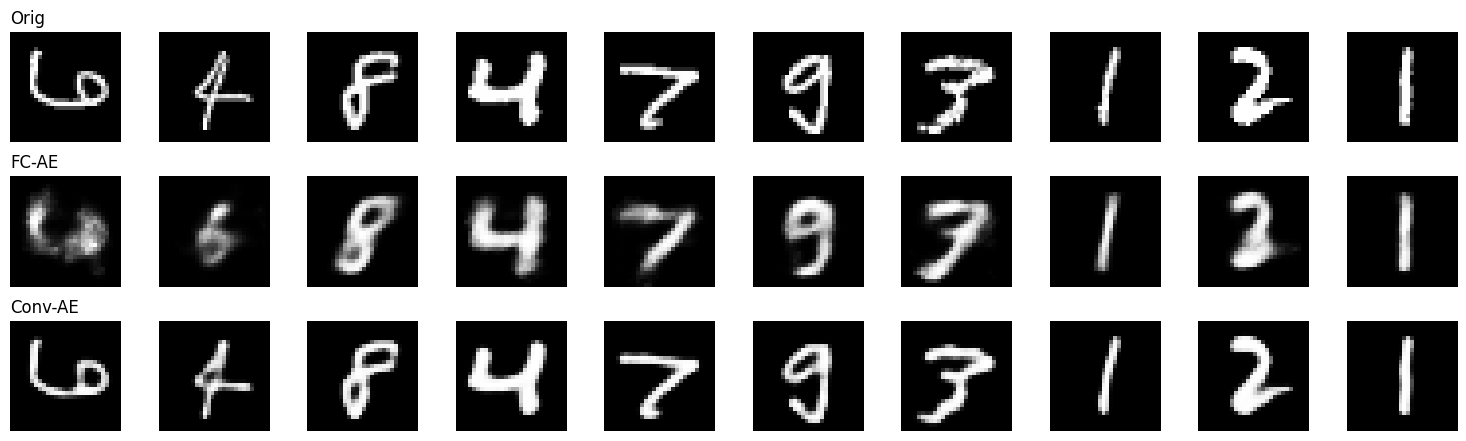

[Inference - Plot 3]: The Convolutional Autoencoder produces significantly sharper edges and structural fidelity compared to the FC-AE. Preserving spatial locality allows the CAE filters to reconstruct contiguous strokes rather than disconnected pixel intensities.


In [6]:
print("\n--- 2. CONVOLUTIONAL AUTOENCODER (CAE) ---")
K.clear_session()
gc.collect()

# Build CAE
cae_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', padding='same')(cae_input)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
latent_cae = layers.Conv2D(64, 3, activation='relu', padding='same')(x) # Latent Feature Map (7x7x64)

x = layers.UpSampling2D(2)(latent_cae)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
cae_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

cae = models.Model(cae_input, cae_output)
cae.compile(optimizer='adam', loss='binary_crossentropy')

start_time = time.time()
cae.fit(X_train_sp, X_train_sp, epochs=20, batch_size=128, validation_data=(X_test_sp, X_test_sp), verbose=0)
cae_time = time.time() - start_time

X_pred_cae = cae.predict(X_test_sp, verbose=0)
mse_cae, mae_cae, ssim_cae = evaluate_reconstruction(X_test_sp, X_pred_cae)

global_metrics['Conv. Autoencoder'] = {'MSE': mse_cae, 'MAE': mae_cae, 'SSIM': ssim_cae, 'Params': cae.count_params(), 'Time': cae_time}

# Plot 3: FC vs CAE Comparison
plt.figure(figsize=(15, 4.5))
for i, idx in enumerate(indices[:10]):
    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test[idx], cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Orig", loc='left')
    # FC-AE
    plt.subplot(3, 10, i + 11)
    plt.imshow(X_pred_fc[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("FC-AE", loc='left')
    # CAE
    plt.subplot(3, 10, i + 21)
    plt.imshow(X_pred_cae[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Conv-AE", loc='left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_03_FC_vs_CAE.png")
plt.show()
print("[Inference - Plot 3]: The Convolutional Autoencoder produces significantly sharper edges and structural fidelity compared to the FC-AE. Preserving spatial locality allows the CAE filters to reconstruct contiguous strokes rather than disconnected pixel intensities.")


--- 3. DENOISING CONVOLUTIONAL AUTOENCODER (DCAE) ---


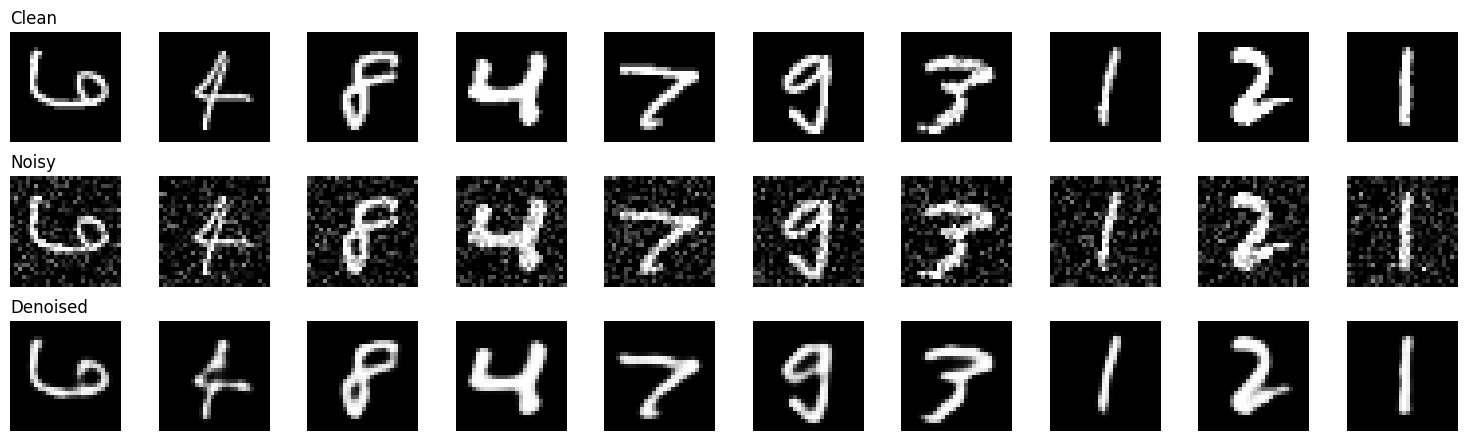

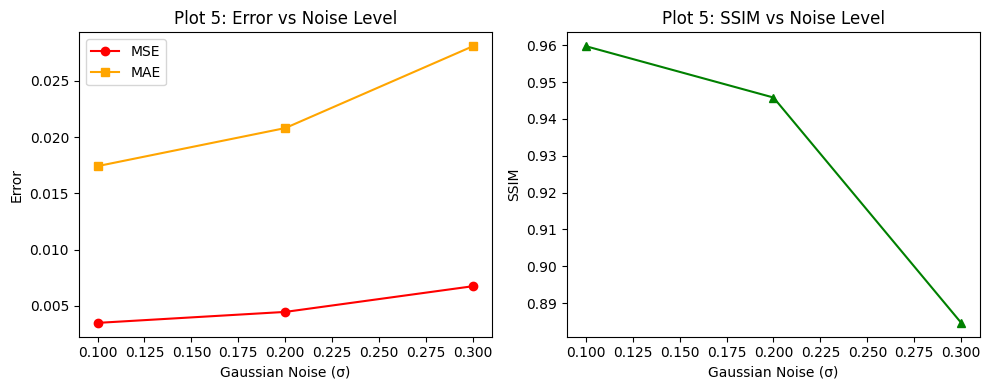

[Inference - Plots 4 & 5]: The DCAE successfully learns to ignore uncorrelated noise, recovering the underlying digit structure. However, as noise reaches σ=0.3, SSIM drops because heavy noise irreparably corrupts critical structural boundaries.


In [7]:
print("\n--- 3. DENOISING CONVOLUTIONAL AUTOENCODER (DCAE) ---")

def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(loc=0.0, scale=sigma, size=images.shape)
    return np.clip(noisy, 0., 1.)

# Train with baseline noise 0.2
X_train_noisy = add_gaussian_noise(X_train_sp, 0.2)
X_test_noisy = add_gaussian_noise(X_test_sp, 0.2)

K.clear_session()
# Clone CAE architecture for Denoising
dcae_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', padding='same')(dcae_input)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
dcae_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

dcae = models.Model(dcae_input, dcae_output)
dcae.compile(optimizer='adam', loss='binary_crossentropy')

start_time = time.time()
# Target is CLEAN images (X_train_sp)
dcae.fit(X_train_noisy, X_train_sp, epochs=20, batch_size=128, validation_data=(X_test_noisy, X_test_sp), verbose=0)
dcae_time = time.time() - start_time

# Predict on baseline 0.2 noise
X_pred_denoised = dcae.predict(X_test_noisy, verbose=0)
mse_dc, mae_dc, ssim_dc = evaluate_reconstruction(X_test_sp, X_pred_denoised)
global_metrics['Denoising CAE'] = {'MSE': mse_dc, 'MAE': mae_dc, 'SSIM': ssim_dc, 'Params': dcae.count_params(), 'Time': dcae_time}

# Plot 4: Clean vs Noisy vs Denoised
plt.figure(figsize=(15, 4.5))
for i, idx in enumerate(indices[:10]):
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test[idx], cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Clean", loc='left')
    plt.subplot(3, 10, i + 11)
    plt.imshow(X_test_noisy[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Noisy", loc='left')
    plt.subplot(3, 10, i + 21)
    plt.imshow(X_pred_denoised[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Denoised", loc='left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_04_Denoising.png")
plt.show()

# Plot 5: Noise Level Degradation Test
noise_levels = [0.1, 0.2, 0.3]
mse_list, mae_list, ssim_list = [], [], []

for sigma in noise_levels:
    X_test_n = add_gaussian_noise(X_test_sp, sigma)
    pred_n = dcae.predict(X_test_n, verbose=0)
    m, a, s = evaluate_reconstruction(X_test_sp, pred_n)
    mse_list.append(m); mae_list.append(a); ssim_list.append(s)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(noise_levels, mse_list, marker='o', color='red', label='MSE')
plt.plot(noise_levels, mae_list, marker='s', color='orange', label='MAE')
plt.title("Plot 5: Error vs Noise Level"); plt.xlabel("Gaussian Noise (\u03C3)"); plt.ylabel("Error"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(noise_levels, ssim_list, marker='^', color='green')
plt.title("Plot 5: SSIM vs Noise Level"); plt.xlabel("Gaussian Noise (\u03C3)"); plt.ylabel("SSIM")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_05_NoiseDegradation.png")
plt.show()
print("[Inference - Plots 4 & 5]: The DCAE successfully learns to ignore uncorrelated noise, recovering the underlying digit structure. However, as noise reaches \u03C3=0.3, SSIM drops because heavy noise irreparably corrupts critical structural boundaries.")

# Store noise table data for later
global_metrics['Noise_Table'] = {'Levels': noise_levels, 'MSE': mse_list, 'MAE': mae_list, 'SSIM': ssim_list}


--- 4. VARIATIONAL AUTOENCODER (VAE) ---
Training VAE... (This will take a minute)


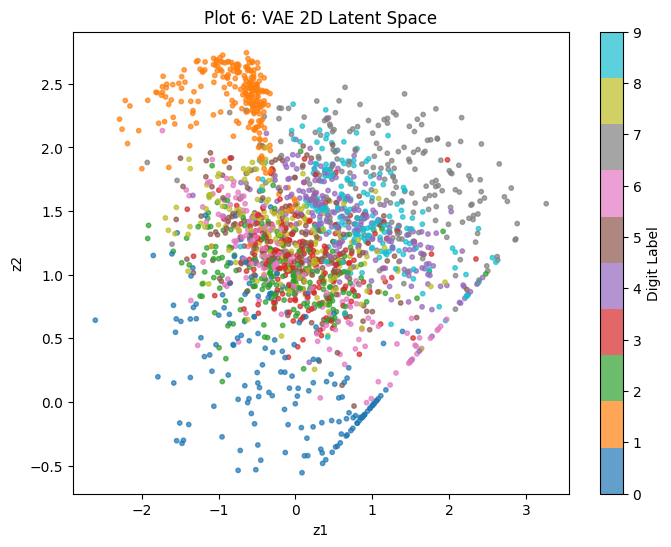

[Inference - Plot 6]: Samples of the same digit group tightly into distinct clusters. Overlaps exist between visually similar digits (like 4 and 9) because the KL-divergence forces a continuous, packed probabilistic distribution.


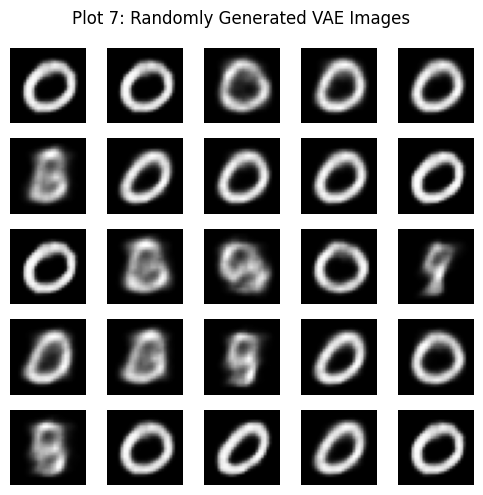

[Inference - Plot 7]: By sampling from N(0,I), the VAE generates entirely new, recognizable digits. Unclear or morphed samples occur when sampling from transition boundaries between clusters in the latent space.


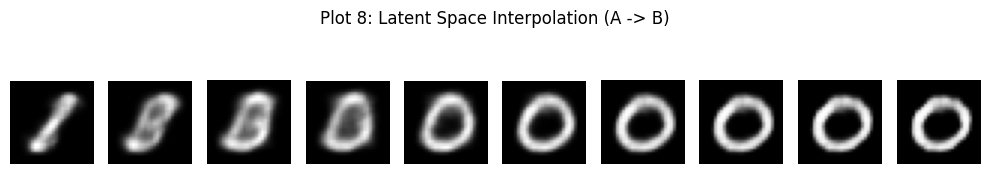

[Inference - Plot 8]: The decoded image morphs smoothly from one digit to another. This proves the VAE latent space is continuous and lacks abrupt, meaningless gaps.


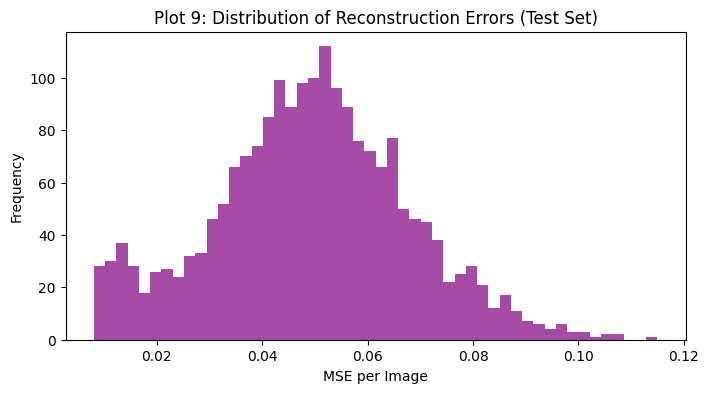

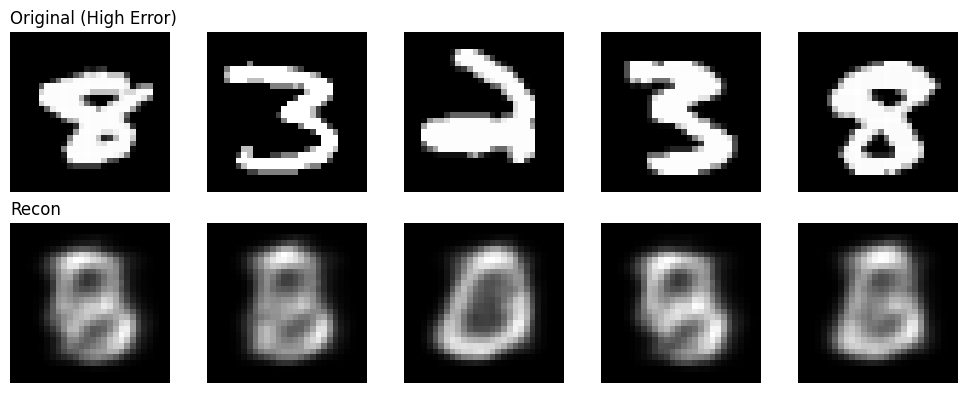

[Inference - High Error Images]: Images with the highest reconstruction errors are almost always sloppily drawn, oddly slanted, or contain thick broken loops that the VAE's generalized 2D latent space fails to perfectly encode.


In [8]:
print("\n--- 4. VARIATIONAL AUTOENCODER (VAE) ---")
K.clear_session()
gc.collect()

# Reparameterization Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# VAE Encoder
vae_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(vae_input)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)
z_mean = layers.Dense(2, name='z_mean')(x)
z_log_var = layers.Dense(2, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(vae_input, [z_mean, z_log_var, z], name='encoder')

# VAE Decoder
latent_inputs = layers.Input(shape=(2,))
x = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
vae_output = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
decoder = models.Model(latent_inputs, vae_output, name='decoder')

# Keras 3 Compatible VAE Subclass
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple): data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.recon_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple): data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.recon_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

# Instantiate and Train VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

start_time = time.time()
print("Training VAE... (This will take a minute)")
hist_vae = vae.fit(X_train_sp, epochs=20, batch_size=128, validation_data=(X_test_sp, X_test_sp), verbose=0)
vae_time = time.time() - start_time

X_pred_vae = vae.predict(X_test_sp, verbose=0)
mse_vae, mae_vae, ssim_vae = evaluate_reconstruction(X_test_sp, X_pred_vae)

# Compute explicit losses for reporting
z_mean_test, z_log_var_test, _ = encoder.predict(X_test_sp, verbose=0)
bce_matrix = tf.keras.losses.binary_crossentropy(X_test_sp, X_pred_vae).numpy()
test_recon_loss = np.mean(np.sum(bce_matrix, axis=(1, 2)))
test_kl_loss = -0.5 * np.mean(np.sum(1 + z_log_var_test - np.square(z_mean_test) - np.exp(z_log_var_test), axis=1))
test_total_loss = test_recon_loss + test_kl_loss

global_metrics['VAE'] = {'MSE': mse_vae, 'MAE': mae_vae, 'SSIM': ssim_vae, 'Params': encoder.count_params() + decoder.count_params(), 'Time': vae_time, 'ReconLoss': test_recon_loss, 'KLLoss': test_kl_loss, 'TotalLoss': test_total_loss}

# Plot 6: Latent Space Visualization
z_means, _, _ = encoder.predict(X_test_sp, verbose=0)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_means[:, 0], z_means[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, label="Digit Label")
plt.title("Plot 6: VAE 2D Latent Space")
plt.xlabel("z1"); plt.ylabel("z2")
plt.savefig(f"{PLOTS_DIR}/Plot_06_VAE_Latent.png")
plt.show()
print("[Inference - Plot 6]: Samples of the same digit group tightly into distinct clusters. Overlaps exist between visually similar digits (like 4 and 9) because the KL-divergence forces a continuous, packed probabilistic distribution.")

# Plot 7: Randomly Generated Images
plt.figure(figsize=(5, 5))
random_z = np.random.normal(0, 1, size=(25, 2))
gen_imgs = decoder.predict(random_z, verbose=0)
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray'); plt.axis('off')
plt.suptitle("Plot 7: Randomly Generated VAE Images")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_07_VAE_Generated.png")
plt.show()
print("[Inference - Plot 7]: By sampling from N(0,I), the VAE generates entirely new, recognizable digits. Unclear or morphed samples occur when sampling from transition boundaries between clusters in the latent space.")

# Plot 8: Latent Space Interpolation
plt.figure(figsize=(10, 2))
z_A = np.array([-2.0, 2.0])
z_B = np.array([2.0, -2.0])
alphas = np.linspace(0, 1, 10)
for i, a in enumerate(alphas):
    z_interp = (1 - a) * z_A + a * z_B
    img_interp = decoder.predict(z_interp.reshape(1, 2), verbose=0)
    plt.subplot(1, 10, i + 1)
    plt.imshow(img_interp.squeeze(), cmap='gray'); plt.axis('off')
plt.suptitle("Plot 8: Latent Space Interpolation (A -> B)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_08_VAE_Interpolation.png")
plt.show()
print("[Inference - Plot 8]: The decoded image morphs smoothly from one digit to another. This proves the VAE latent space is continuous and lacks abrupt, meaningless gaps.")

# Plot 9: Distribution of Reconstruction Errors
errors = np.mean((X_test_sp - X_pred_vae)**2, axis=(1, 2, 3))
plt.figure(figsize=(8, 4))
plt.hist(errors, bins=50, color='purple', alpha=0.7)
plt.title("Plot 9: Distribution of Reconstruction Errors (Test Set)")
plt.xlabel("MSE per Image"); plt.ylabel("Frequency")
plt.savefig(f"{PLOTS_DIR}/Plot_09_Error_Dist.png")
plt.show()

# High Error Analysis
high_error_idx = np.argsort(errors)[-5:] # Top 5 highest errors
plt.figure(figsize=(10, 4))
for i, idx in enumerate(high_error_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_sp[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Original (High Error)", loc='left')
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_pred_vae[idx].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: plt.title("Recon", loc='left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/High_Error_Images.png")
plt.show()
print("[Inference - High Error Images]: Images with the highest reconstruction errors are almost always sloppily drawn, oddly slanted, or contain thick broken loops that the VAE's generalized 2D latent space fails to perfectly encode.")


--- 5. LATENT DIMENSION STUDY & EXPORT ---


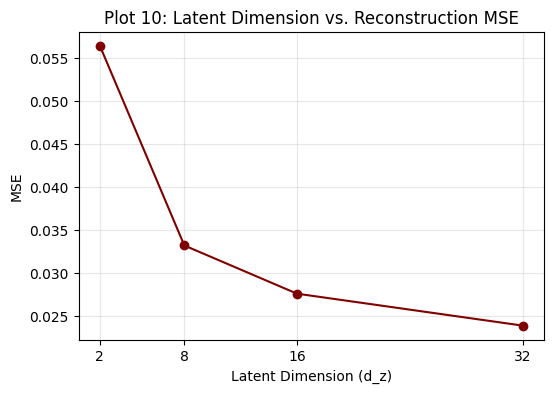

[Inference - Plot 10]: As latent dimension increases, MSE strictly decreases. However, extreme compression (d=2) causes severe information loss, while high dimensions (d=32) approach near-perfect identity mapping but lose their utility as feature compressors.

Writing tables to Results directory...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All Autoencoder models trained, plots generated, and results exported successfully!


In [9]:
import shutil
from google.colab import files

print("\n--- 5. LATENT DIMENSION STUDY & EXPORT ---")
latent_dims = [2, 8, 16, 32]
dim_mse, dim_ssim, dim_params = [], [], []

for d in latent_dims:
    K.clear_session()
    inp = layers.Input(shape=(784,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    lat = layers.Dense(d, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(lat)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid')(x)

    m = models.Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    m.fit(X_train_flat, X_train_flat, epochs=10, batch_size=128, verbose=0)

    pred = m.predict(X_test_flat, verbose=0)
    err, _, ssm = evaluate_reconstruction(X_test_flat, pred, is_flat=True)
    dim_mse.append(err); dim_ssim.append(ssm); dim_params.append(m.count_params())

# Plot 10: Latent Dimension vs MSE
plt.figure(figsize=(6, 4))
plt.plot(latent_dims, dim_mse, marker='o', color='maroon')
plt.title("Plot 10: Latent Dimension vs. Reconstruction MSE")
plt.xlabel("Latent Dimension (d_z)"); plt.ylabel("MSE")
plt.xticks(latent_dims)
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOTS_DIR}/Plot_10_Latent_Dim.png")
plt.show()
print("[Inference - Plot 10]: As latent dimension increases, MSE strictly decreases. However, extreme compression (d=2) causes severe information loss, while high dimensions (d=32) approach near-perfect identity mapping but lose their utility as feature compressors.")

print("\nWriting tables to Results directory...")
with open(os.path.join(RESULTS_DIR, 'Experiment_7_AE_Results.txt'), 'w') as f:
    f.write("=== TABLE 1: RECONSTRUCTION COMPARISON (Section 11) ===\n")
    f.write(f"{'Model':<25} | {'MSE':<10} | {'MAE':<10} | {'SSIM':<10} | {'Parameters':<10}\n")
    f.write("-" * 75 + "\n")
    f.write(f"{'Fully Connected AE':<25} | {global_metrics['FC Autoencoder']['MSE']:<10.4f} | {global_metrics['FC Autoencoder']['MAE']:<10.4f} | {global_metrics['FC Autoencoder']['SSIM']:<10.4f} | {global_metrics['FC Autoencoder']['Params']:<10}\n")
    f.write(f"{'Convolutional AE':<25} | {global_metrics['Conv. Autoencoder']['MSE']:<10.4f} | {global_metrics['Conv. Autoencoder']['MAE']:<10.4f} | {global_metrics['Conv. Autoencoder']['SSIM']:<10.4f} | {global_metrics['Conv. Autoencoder']['Params']:<10}\n")
    f.write(f"{'Denoising CAE':<25} | {global_metrics['Denoising CAE']['MSE']:<10.4f} | {global_metrics['Denoising CAE']['MAE']:<10.4f} | {global_metrics['Denoising CAE']['SSIM']:<10.4f} | {global_metrics['Denoising CAE']['Params']:<10}\n")

    f.write("\n=== TABLE 2: NOISE LEVEL vs RECONSTRUCTION (Section 14) ===\n")
    f.write(f"{'Noise Level':<15} | {'MSE':<10} | {'MAE':<10} | {'SSIM':<10}\n")
    f.write("-" * 55 + "\n")
    for i, lv in enumerate(global_metrics['Noise_Table']['Levels']):
        f.write(f"{lv:<15.1f} | {global_metrics['Noise_Table']['MSE'][i]:<10.4f} | {global_metrics['Noise_Table']['MAE'][i]:<10.4f} | {global_metrics['Noise_Table']['SSIM'][i]:<10.4f}\n")

    f.write("\n=== TABLE 3: VAE METRICS (Section 21) ===\n")
    f.write(f"Reconstruction Loss : {global_metrics['VAE']['ReconLoss']:.4f}\n")
    f.write(f"KL Loss             : {global_metrics['VAE']['KLLoss']:.4f}\n")
    f.write(f"Total Loss          : {global_metrics['VAE']['TotalLoss']:.4f}\n")
    f.write(f"Test MSE            : {global_metrics['VAE']['MSE']:.4f}\n")
    f.write(f"Test MAE            : {global_metrics['VAE']['MAE']:.4f}\n")
    f.write(f"Mean SSIM           : {global_metrics['VAE']['SSIM']:.4f}\n")

    f.write("\n=== TABLE 4: LATENT DIMENSION STUDY (Section 27) ===\n")
    f.write(f"{'Latent Dimension':<20} | {'MSE':<10} | {'SSIM':<10} | {'Parameters':<10}\n")
    f.write("-" * 60 + "\n")
    for i, d in enumerate(latent_dims):
        f.write(f"{d:<20} | {dim_mse[i]:<10.4f} | {dim_ssim[i]:<10.4f} | {dim_params[i]:<10}\n")

    f.write("\n=== TABLE 5: CONSOLIDATED RESULTS (Section 25) ===\n")
    f.write(f"{'Model':<25} | {'MSE':<10} | {'MAE':<10} | {'SSIM':<10} | {'Parameters':<15} | {'Time (s)':<10}\n")
    f.write("-" * 90 + "\n")
    for m in ['FC Autoencoder', 'Conv. Autoencoder', 'Denoising CAE', 'VAE']:
        f.write(f"{m:<25} | {global_metrics[m]['MSE']:<10.4f} | {global_metrics[m]['MAE']:<10.4f} | {global_metrics[m]['SSIM']:<10.4f} | {global_metrics[m]['Params']:<15} | {global_metrics[m]['Time']:<10.2f}\n")

# Zip and Download
shutil.make_archive('Exp7_Autoencoder_Plots', 'zip', PLOTS_DIR)
shutil.make_archive('Exp7_Autoencoder_Results', 'zip', RESULTS_DIR)
files.download('Exp7_Autoencoder_Plots.zip')
files.download('Exp7_Autoencoder_Results.zip')

print("All Autoencoder models trained, plots generated, and results exported successfully!")


--- GENERATING PLOT 9 ---


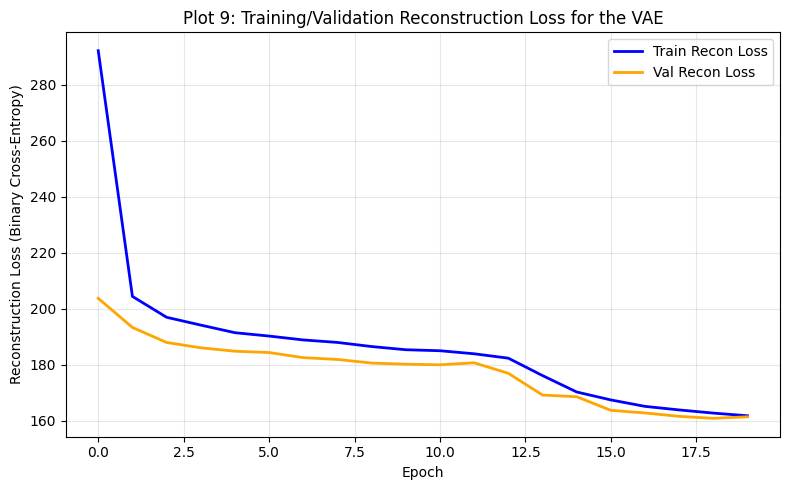

[Inference - Plot 9]: Both training and validation reconstruction losses decrease smoothly and converge without significant overfitting. The validation loss tracks closely with the training loss, indicating the VAE is successfully learning to reliably reconstruct unseen digits from its probabilistic latent space.


In [10]:
import os
import matplotlib.pyplot as plt

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------------------------------------------------------
# Plot 9: Training/validation reconstruction loss for the VAE
# ---------------------------------------------------------
print("\n--- GENERATING PLOT 9 ---")

# Extract the specific reconstruction loss from the VAE training history
train_recon_loss = hist_vae.history['recon_loss']
val_recon_loss = hist_vae.history['val_recon_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_recon_loss, label='Train Recon Loss', color='blue', linewidth=2)
plt.plot(val_recon_loss, label='Val Recon Loss', color='orange', linewidth=2)
plt.title("Plot 9: Training/Validation Reconstruction Loss for the VAE")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (Binary Cross-Entropy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Plot_09_VAE_Recon_Loss.png", bbox_inches='tight')
plt.show()

print("[Inference - Plot 9]: Both training and validation reconstruction losses decrease smoothly and converge without significant overfitting. The validation loss tracks closely with the training loss, indicating the VAE is successfully learning to reliably reconstruct unseen digits from its probabilistic latent space.")